## 006 - AppleCider multimodal
<a id='index'></a> <br>

- [part 0: config](#config)
- [part 1: DataGenerator](#data)
    - [example object in Dataset (includes alert.npy)](#ex)
    - [processed photometry vs normalized flux in dataset](#process)
    - [plot photometry, images, spectra, (metadata is also there)](#stuff)
- [part 2: DataLoader](#dataload)


In [1]:
import os
import sys
sys.path.insert(0, '/AppleCider/')

import joblib
import numpy as np
import pandas as pd

from scipy.interpolate import interp1d
from scipy import stats
from datetime import datetime
import wandb
from tqdm.auto import tqdm
import pickle

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

## so many plots
import AppleCider.preprocess.plot_data as plot_data
from AppleCider.preprocess.plot_data import plot_images
import AppleCider.preprocess.more_info as more_info
from AppleCider.preprocess.plot_data import plot_dataset

## model stuff
from AppleCider.core.model import Informer, GalSpecNet, MetaModel, BTSModel, AstroM4

from AppleCider.core.dataset import DataGenerator

from tqdm.auto import tqdm
import pickle

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch import nn
from torch.optim.lr_scheduler import ExponentialLR, ReduceLROnPlateau, LinearLR


import AppleCider.core.drink as drink


In [2]:
from AppleCider.preprocess.transient_dataset import TransientDataset
from AppleCider.preprocess.data_preprocessor import AlertProcessor, PhotometryProcessor
from AppleCider.preprocess.data_preprocessor import DataPreprocessor, SpectraProcessor
from AppleCider.preprocess.data_preprocessor import DataSorter

In [12]:
CLASSES = ['SN Ia', 'SN II', 'SN IIP', 'Cataclysmic', 'AGN', 'SN IIn', 'SN Ic', 'SN Ib', 'SN IIb', 'Tidal Disruption Event']
data_dir = '../SEDM_folder'

data_test = pd.read_csv('../csv-pkl/data_test_BTS.csv')
data_train = pd.read_csv('../csv-pkl/data_train_BTS.csv')

SEDM_dataset = pd.read_csv('../csv-pkl/SEDM_BrightTransientSurvey.csv')

In [4]:
TRAIN_DATA_PATH = '../data_train_BTS'
TEST_DATA_PATH = '../data_test_BTS'

In [5]:
## obj_id, type for every object with SEDM spectra
SEDM_dataset[:2]

,obj_id,type
0,ZTF18aatfxtd,SN Ia
1,ZTF18aawppyt,SN Ia


<big>part 0: config</big>

<a id='config'></a>

<u>what paths / files do i need?</u>
- preprocessed data from the [Bright Transient Survey](https://sites.astro.caltech.edu/ztf/bts/). the steps/formating are outlined in `001-data-processing.ipynb`. from that notebook specifically you'll need:
    - data_train_BTS.csv (`config[df_path]`) <small>(csv included in repo) </small>
    - preprocessed data (`config[preprocessed_path]`) for `data_train_BTS`, `data_test_BTS` <small>(<i>NOT</i> included in repo) </small>
    
- from DataGenerator:
    - train_files_BTS.pkl (`config[train_files_path]`), val_files_BTS.pkl (`config[val_files_path]`) created in `001-data-processing.ipynb`. <small>(included in repo) </small> alternatively, select `config[generate_train_val_files]: True`, will generate new train, val files to their respective paths.
    - scaler_BTS.pkl (`config[scaler_path]`) created in `003-AppleCider-metadata.ipynb`.
    
    
<i><small>[back to index](#index)</small></i>

In [29]:
config = {
        'project': 'AppleCider',
        'mode': 'all',    # 'clip' 'photo' 'spectra' 'meta' 'image' 'all'
        'config_from': None,
        'random_seed': 42,  # 42, 66, 0, 12, 123
        'use_wandb': True,
        'save_weights': True,
        'weights_path': f'../AppleCider/weights/multimodal_BTS/',
        'use_pretrain': None,
        'freeze': False,

        ## Data General
        'preprocessed_path':'../data_train_BTS',
        'df_path': '../csv-pkl/data_train_BTS.csv',
        ## train, val files 
        'generate_train_val_files': False,
        'class_weights': False,
        'train_files_path': '../csv-pkl/train_files_BTS.pkl',
        'val_files_path': '../csv-pkl/val_files_BTS.pkl',
        'class_weights_path': '../csv-pkl/class_weights_BTS.pkl',
    
        'step': 'type',
        'classes': CLASSES,
        'group_labels': False,
        'max_samples': 1000,
        'num_classes': len(CLASSES),

        ## Photometry Model
        'seq_len': 230,
        'p_enc_in': 4,
        'p_d_model': 128,
        'p_dropout': 0.2,
        'p_factor': 1,
        'p_output_attention': False,
        'p_n_heads': 12,
        'p_d_ff': 512,
        'p_activation': 'gelu',
        'p_e_layers': 8,

        # Spectra Model
        's_dropout': 0.2, 
        's_conv_channels': [1, 64, 64, 32, 32],
        's_kernel_size': 3,
        's_mp_kernel_size': 4,

        # Metadata Model
        'm_hidden_dim': 512,
        'm_dropout': 0.2,
        'meta_cols': range(10),
        'scaler_path': '../csv-pkl/scaler_BTS.pkl',

        # Image Model
        'input_channels': 3,
        'conv1_channels': 64,
        'conv2_channels': 16,
        'conv_kernel': 3,
        'conv_dropout1': 0.45,
        'conv_dropout2': 0.65,

        # MultiModal Model
        'hidden_dim': 512,
        'fusion': 'avg',  # 'avg', 'concat'

        # Training
        'batch_size': 512,
        'lr': 0.001,
        'beta1': 0.9,
        'beta2': 0.999,
        'weight_decay': 0.01,
        'epochs':25,
        'early_stopping_patience': 15,
        'scheduler': 'ReduceLROnPlateau',  # 'ExponentialLR', 'ReduceLROnPlateau'
        'gamma': 0.9,  # for ExponentialLR scheduler
        'factor': 0.3,  # for ReduceLROnPlateau scheduler
        'patience': 3,  # for ReduceLROnPlateau scheduler
        'warmup': False,
        'warmup_epochs': 100,
        'clip_grad': False,
        'clip_value': 5
    }

In [30]:
wandb.init(
    project=config['project'],
    config=config)

<a id='Dataset'></a> <br>

<br>

<big>part 1: Dataset</big>


***

<i><small>[back to index](#index)</small></i>

In [21]:
train_dataset = DataGenerator(config=config, split='train')
val_dataset = DataGenerator(config=config, split='val')

<a id='ex'></a>

example object

In [22]:
## you can get the object id from this: 
obj_alert = more_info.give_me_the_original_ish_alert(train_dataset, 2, data_train, TRAIN_DATA_PATH)

obj_id = obj_alert['obj_id']
print(f"ex photometry for {obj_id}:")
photometry = train_dataset[2][0][:13]
photometry

ex photometry for ZTF17aacpbmv:


tensor([[ 0.0000,  0.1740, -0.9270,  0.0000],
        [ 0.0233, -0.9233,  0.1981,  0.0000],
        [ 3.9628, -0.9233,  1.1368,  0.0000],
        [ 4.0588,  1.1515, -0.9270,  0.0000],
        [ 6.0258, -0.9233,  1.4459,  0.0000],
        [ 6.0442,  1.4444, -0.9270,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000]])

In [23]:
print(f"processed alert photometry for {obj_id}:")
obj_alert['photometry']

#obj_alert['metadata']
#obj_alert['images']
#obj_alert['spectra']
#obj_alert['target']
#obj_alert['alert']

processed alert photometry for ZTF17aacpbmv:


array([[ 0.        ,  0.17401156, -0.92695588,  0.        ],
       [ 0.0232639 , -0.92330324,  0.19813732,  0.        ],
       [ 3.9628125 , -0.92330324,  1.13684653,  0.        ],
       [ 4.0587963 ,  1.15147438, -0.92695588,  0.        ],
       [ 6.0258102 , -0.92330324,  1.4458838 ,  0.        ],
       [ 6.0441782 ,  1.44442379, -0.92695588,  0.        ]])

<a id='process'></a>

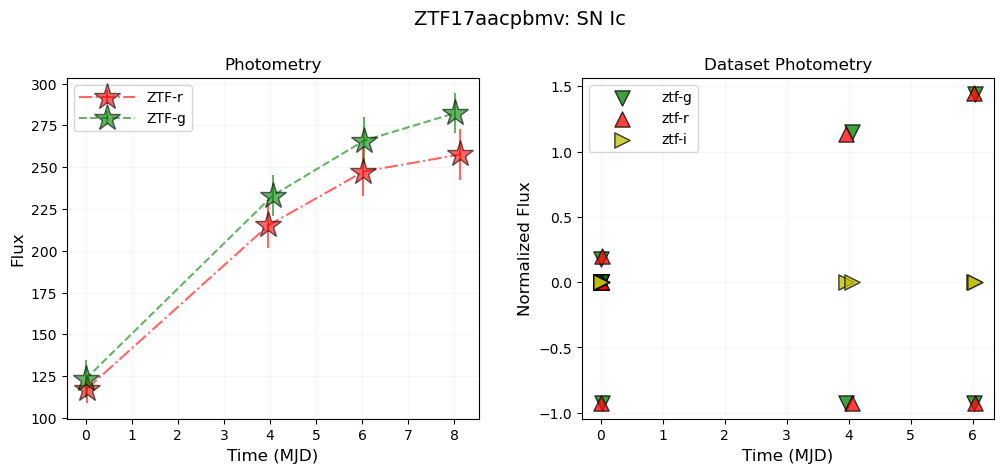

In [24]:
## plot 1 is the original photometry, cut off at 10 days
plot_dataset.compare_dataset_photometry(photometry, obj_id, SEDM_dataset, data_dir)

<a id='stuff'></a>

ZTF17aacpbmv: ZTF17aacpbmv_alert_7.npy
metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0113,  0.1264, -0.9583,  0.2615, -1.2994, -1.0264, -0.2567,  0.0560,
         0.1973, -0.1923])


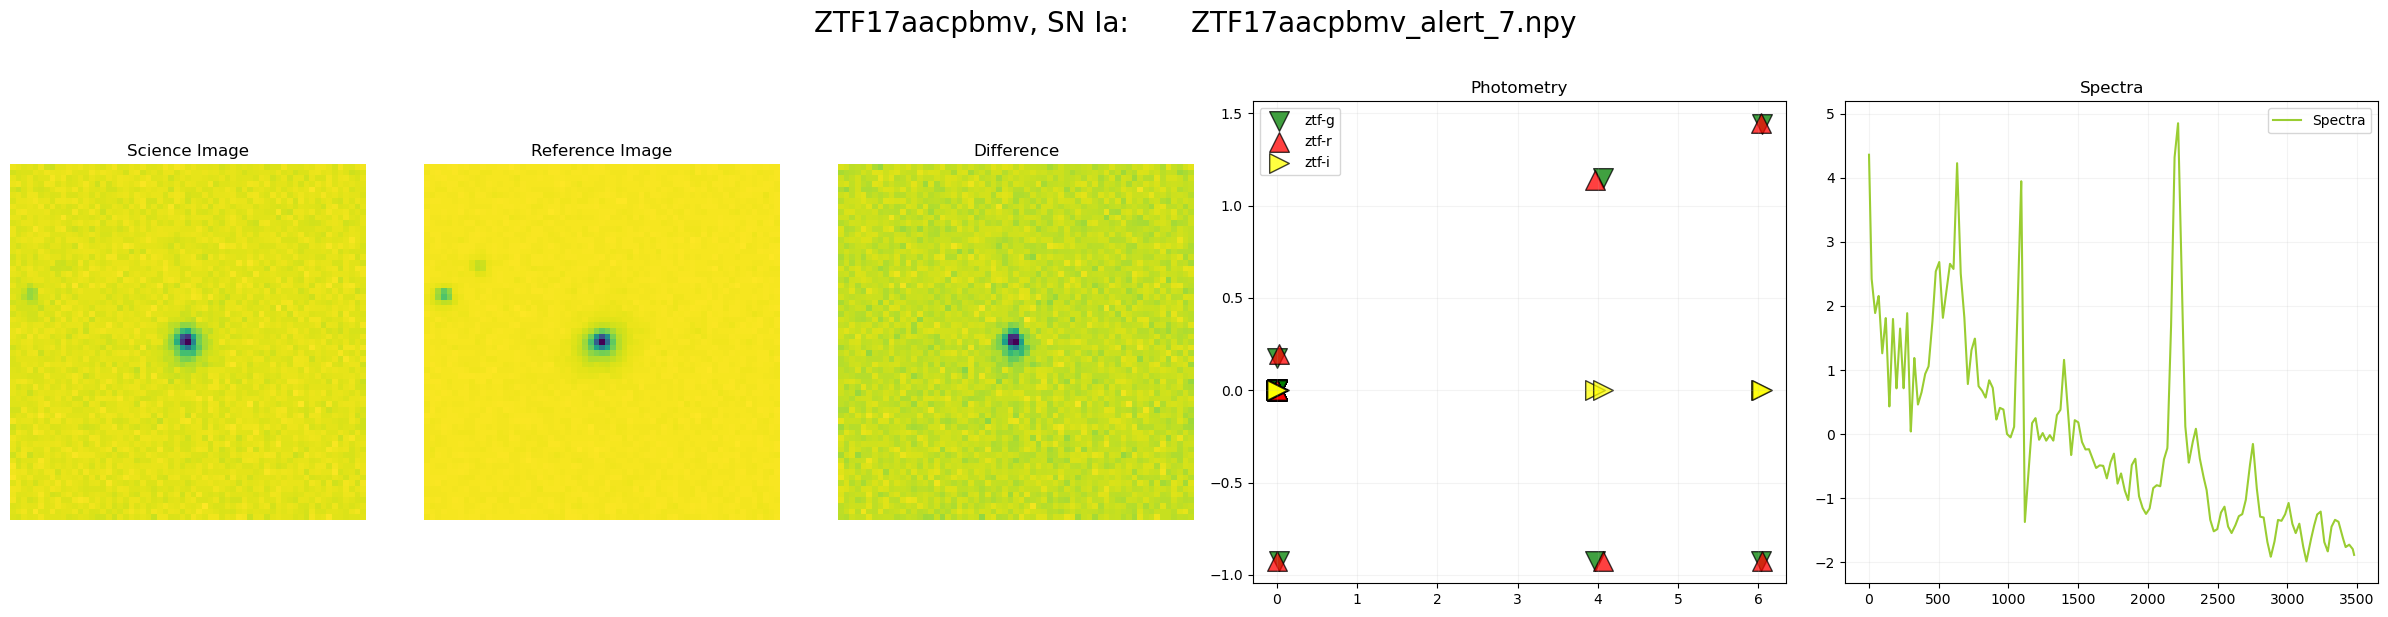

In [14]:
plot_dataset.plot_dataset_item_named(train_dataset, 2, joblib.load('../csv-pkl/train_files_BTS.pkl'))

metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0143,  0.1183, -0.9276,  0.1900, -0.6001,  0.9833, -0.1720, -0.5528,
        -0.9129, -0.2370])


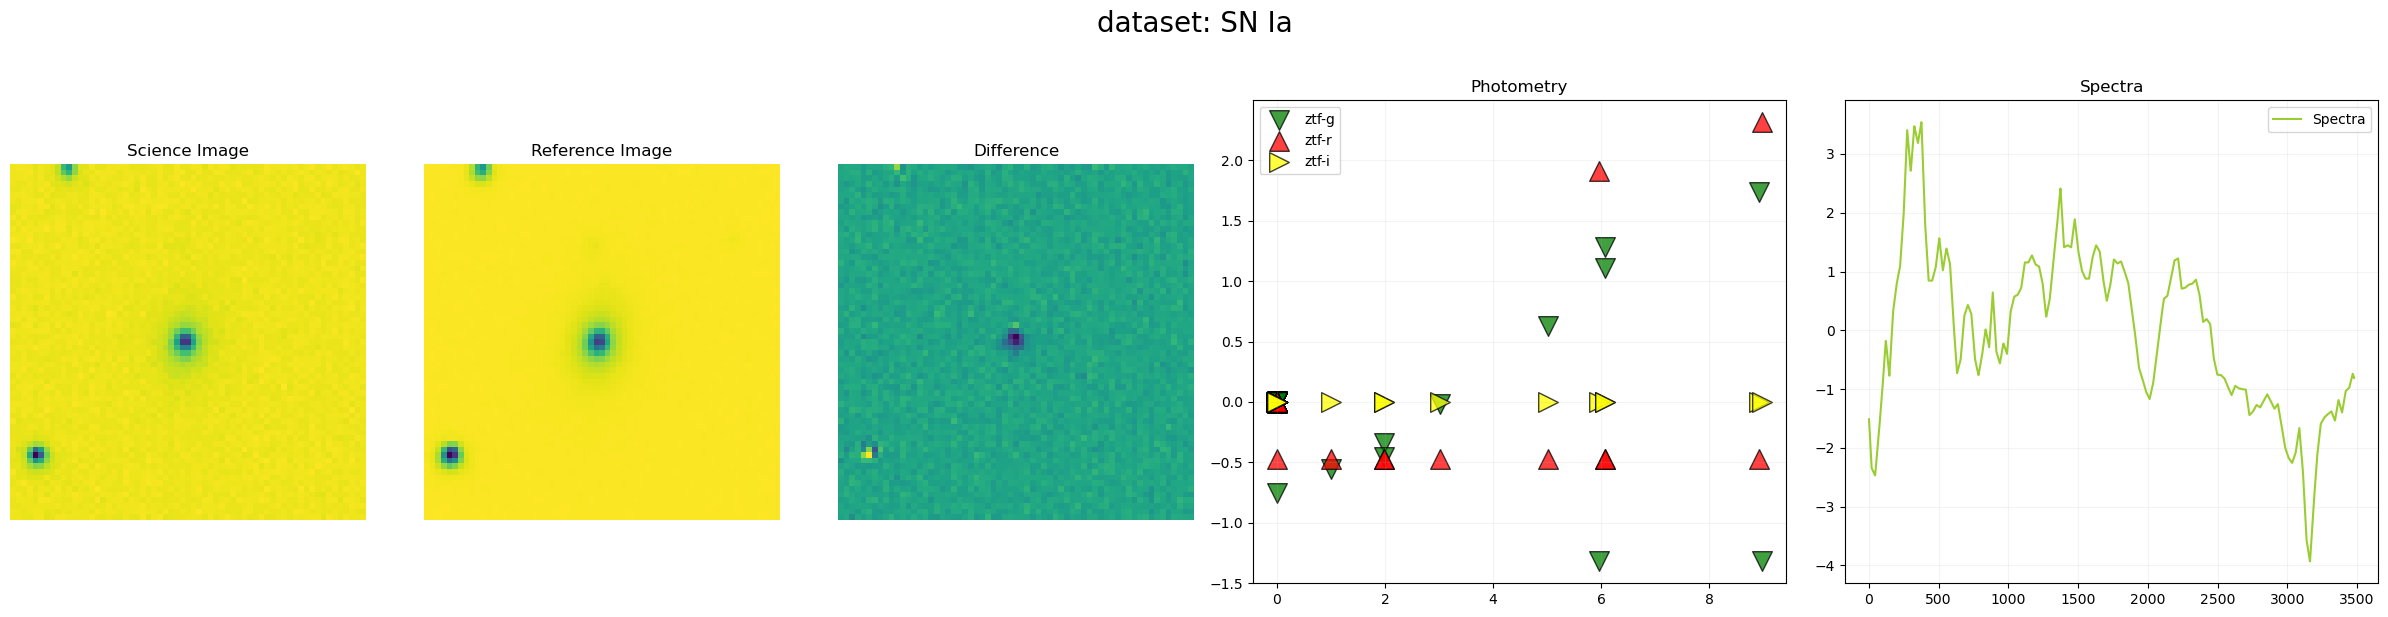

metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0111,  0.1183, -1.0120,  0.1140, -0.5128,  0.2250, -0.2144, -0.6255,
         0.0411, -0.1361])


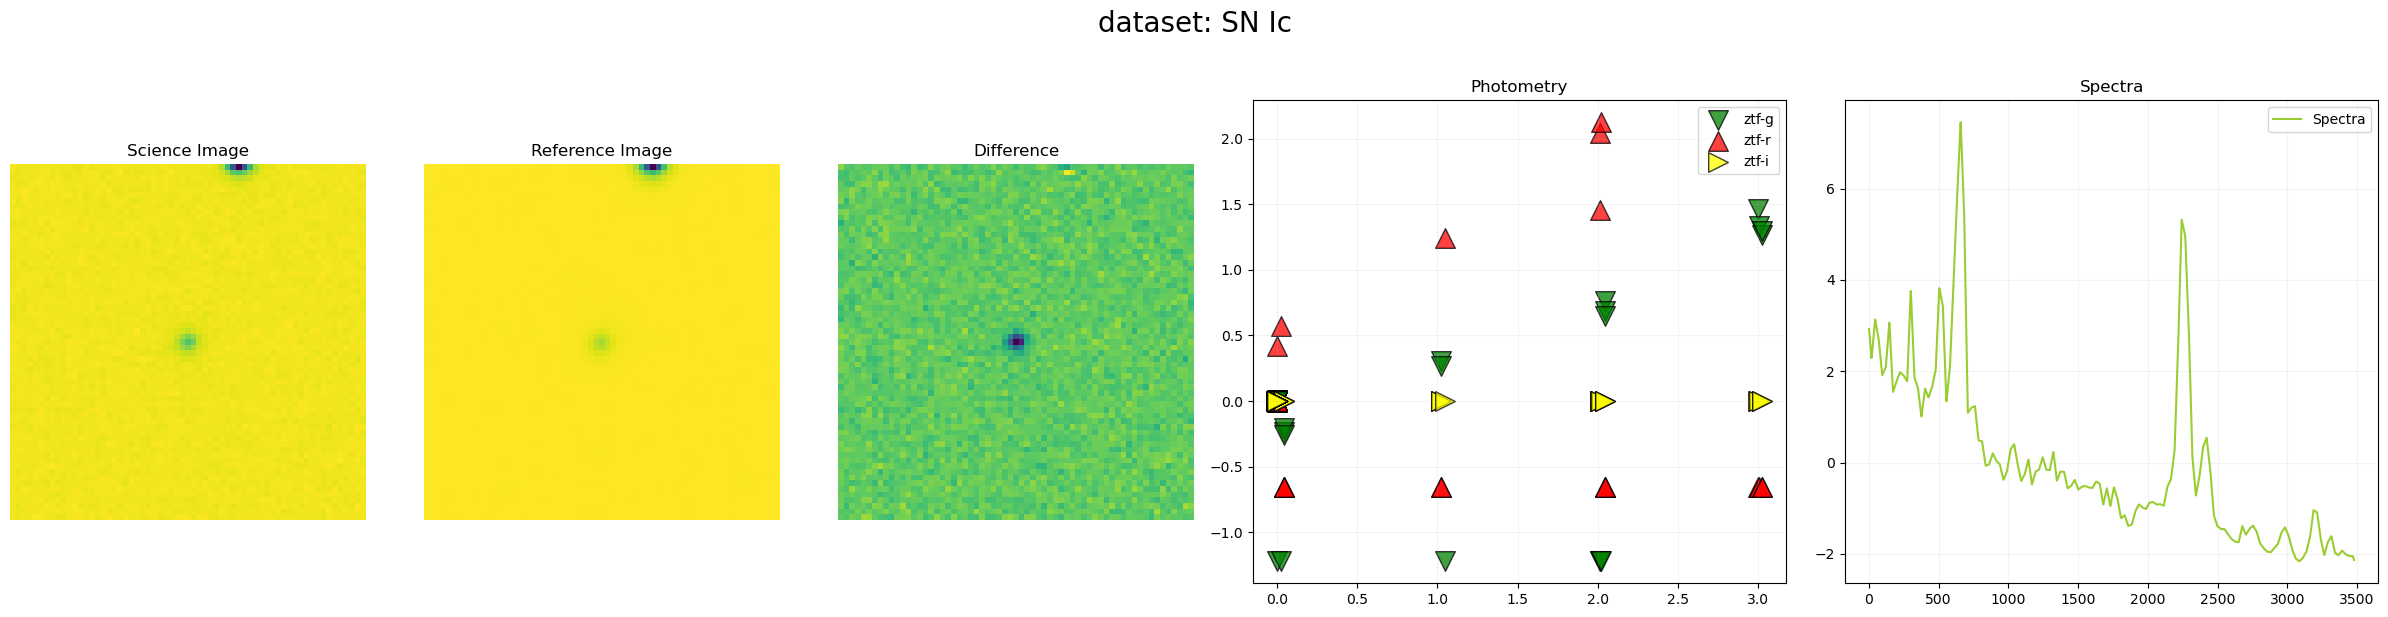

metadata columns: 
 sgscore1, sgscore2, distpsnr1, distpsnr2, ra, dec, nmtchps, sharpnr, scorr, sky 
 tensor([ 0.0111,  0.1183, -1.0007,  0.1140, -0.5128,  0.2250, -0.2144,  0.0483,
        -0.7574,  0.1835])


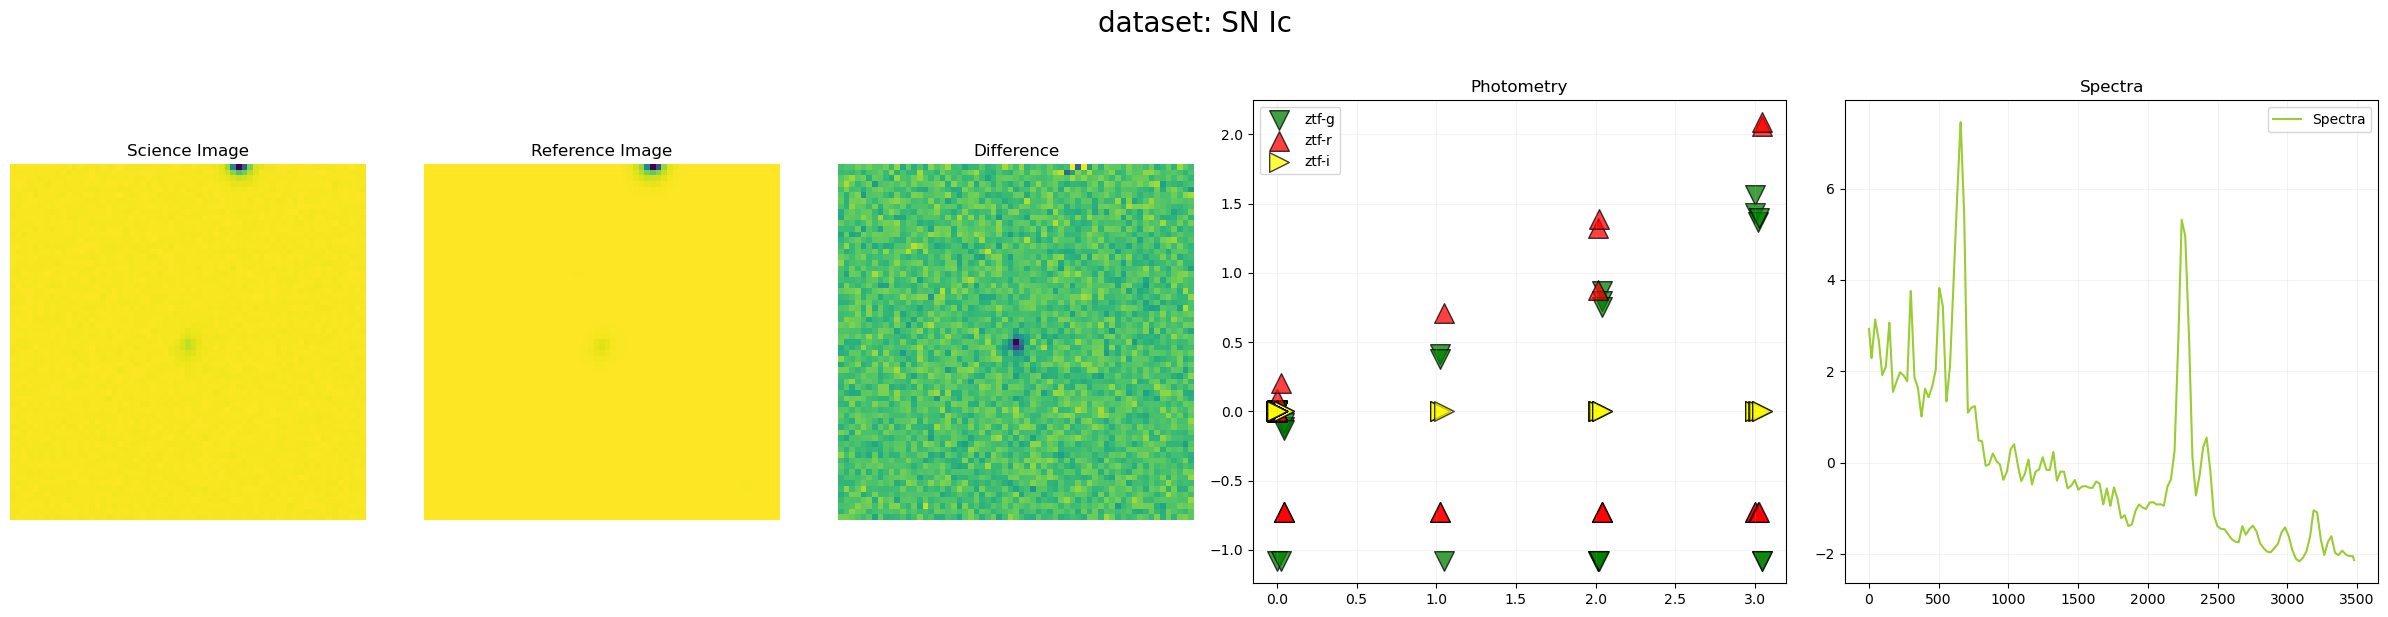

In [15]:
## plot however many you feel like waiting for 
for i in range(12,15):
    plot_dataset.plot_dataset_item(train_dataset, i)

<big>part 2: DataLoader</big>
<a id='dataload'></a>

***
<i><small>[back to index](#index)</small></i>

In [16]:
train_dataloader = DataLoader(train_dataset, batch_size=config['batch_size'], collate_fn = drink.collate_func,
                              shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_dataset, batch_size=config['batch_size'], collate_fn = drink.collate_func,
                              shuffle=True)

In [17]:
batch = next(iter(train_dataloader))
photometry, photometry_mask, metadata, images, spectra, target  = batch

In [18]:
photometry.shape, photometry_mask.shape, metadata.shape, images.shape, spectra.shape, target.shape

(torch.Size([512, 230, 4]),
 torch.Size([512, 230]),
 torch.Size([512, 10]),
 torch.Size([512, 3, 63, 63]),
 torch.Size([512, 1, 3481]),
 torch.Size([512]))

Using cpu


Train:   0%|          | 0/12 [00:00<?, ?it/s]

Validation:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 0: Train Loss 2.3262 	 Val Loss 2.3283 	                     Train Acc 0.0293 	 Val Acc 0.0006


Train:   0%|          | 0/12 [00:00<?, ?it/s]

...

Epoch 23: Train Loss 1.1421 	 Val Loss 1.1358 	                     Train Acc 0.6924 	 Val Acc 0.6149


Train:   0%|          | 0/12 [00:00<?, ?it/s]

Validation:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 24: Train Loss 1.1031 	 Val Loss 1.0867 	                     Train Acc 0.6986 	 Val Acc 0.6464


validation:   0%|          | 0/4 [00:00<?, ?it/s]

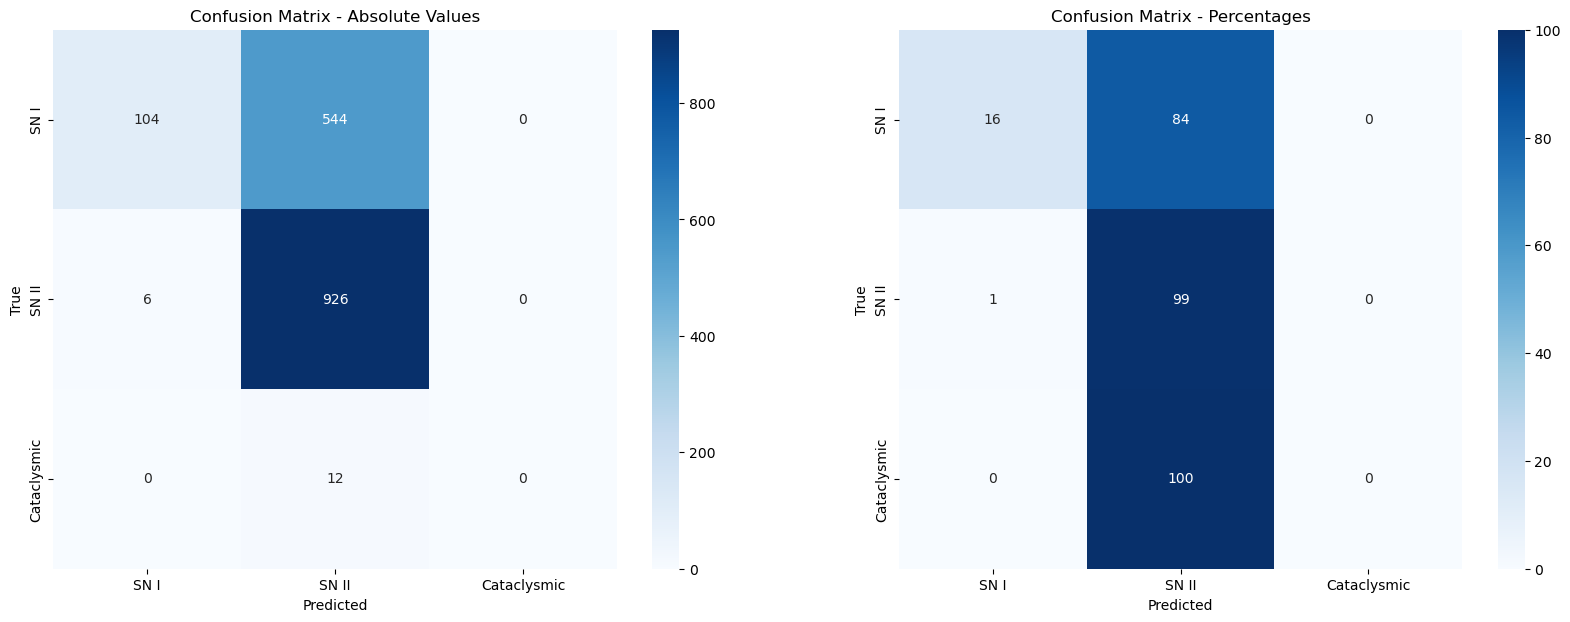

In [31]:
drink.run(config)